In [67]:
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import math
from imblearn.over_sampling import SMOTE
from collections import Counter
from scipy.stats import shapiro, kstest, norm
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler ,FunctionTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, average_precision_score, auc
from sklearn.pipeline import Pipeline

# Data preprocessing and EDA

In [2]:
df = pd.read_csv('/content/Outcomes-a.txt')
df.head()

,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0


In [9]:
zip_path = "/content/set-a.zip"
extract_dir = "/content/set-a"

# Extract the zip first if not already done
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    print("Extraction complete.")

# Find all .txt patient files (handles any nested folders inside the zip)
patient_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".txt"):
            patient_files.append(os.path.join(root, file))

print(f"Found {len(patient_files)} patient files.")

records = []
# Loop through each patient file
for file_path in patient_files:
    file = os.path.basename(file_path)

    # Read patient data
    data_df = pd.read_csv(file_path, header=0, names=["Time", "Parameter", "Value"])
    data_df["Value"] = pd.to_numeric(data_df["Value"], errors="coerce")

    # Replace -1 with NaN (-1 = missing sentinel in this dataset)
    data_df["Value"] = data_df["Value"].replace(-1, np.nan)

    # Extract patient RecordID
    record_id = int(file.replace(".txt", ""))

    # Take mean of numeric columns grouped by parameter
    features = data_df.groupby("Parameter")["Value"].mean()
    features["RecordID"] = record_id

    records.append(features)

# Convert list to dataframe
data = pd.DataFrame(records)
data = data.reset_index(drop=True)
print(f"Patient features shape: {data.shape}")
data.head()

Extraction complete.
Found 4000 patient files.
Patient features shape: (4000, 42)


Parameter,Age,BUN,Creatinine,FiO2,GCS,Gender,Glucose,HCO3,HCT,HR,...,Bilirubin,DiasABP,MAP,MechVent,SaO2,SysABP,Albumin,TroponinI,TroponinT,Cholesterol
0,90.0,36.000000,1.100000,0.618750,13.900000,0.0,106.000000,23.000000,29.900000,90.187500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50.0,15.166667,1.000000,0.464706,8.066667,1.0,147.166667,24.333333,30.511111,112.656716,...,0.76,79.955224,100.134328,1.0,98.0,135.000000,NaN,NaN,NaN,NaN
2,65.0,119.833333,3.000000,0.623529,8.000000,1.0,257.166667,26.166667,27.516667,67.312500,...,2.05,52.603448,70.344828,1.0,95.5,110.551724,3.2,0.8,NaN,NaN
3,72.0,18.000000,1.250000,NaN,NaN,1.0,146.500000,18.000000,35.675000,NaN,...,0.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.211667,NaN
4,64.0,18.333333,0.866667,0.566667,13.166667,1.0,154.600000,24.666667,25.300000,81.568966,...,NaN,54.868421,76.184211,1.0,97.5,125.026316,NaN,NaN,NaN,NaN


In [36]:
merged = pd.merge(data, df, on="RecordID", how="inner")
print(f"Merged shape: {merged.shape}")
merged.head()

Merged shape: (4000, 47)


,Age,BUN,Creatinine,FiO2,GCS,Gender,Glucose,HCO3,HCT,HR,...,SysABP,Albumin,TroponinI,TroponinT,Cholesterol,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,90.0,36.000000,1.100000,0.618750,13.900000,0.0,106.000000,23.000000,29.900000,90.187500,...,NaN,NaN,NaN,NaN,NaN,13,4,3,2,1
1,50.0,15.166667,1.000000,0.464706,8.066667,1.0,147.166667,24.333333,30.511111,112.656716,...,135.000000,NaN,NaN,NaN,NaN,14,9,10,-1,0
2,65.0,119.833333,3.000000,0.623529,8.000000,1.0,257.166667,26.166667,27.516667,67.312500,...,110.551724,3.2,0.8,NaN,NaN,17,14,22,908,0
3,72.0,18.000000,1.250000,NaN,NaN,1.0,146.500000,18.000000,35.675000,NaN,...,NaN,NaN,NaN,0.211667,NaN,-1,1,5,-1,0
4,64.0,18.333333,0.866667,0.566667,13.166667,1.0,154.600000,24.666667,25.300000,81.568966,...,125.026316,NaN,NaN,NaN,NaN,23,9,5,520,0


In [37]:
features = merged.columns.tolist()
print(features)

['Age', 'BUN', 'Creatinine', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K', 'Lactate', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RecordID', 'RespRate', 'Temp', 'Urine', 'WBC', 'Weight', 'pH', 'ALP', 'ALT', 'AST', 'Bilirubin', 'DiasABP', 'MAP', 'MechVent', 'SaO2', 'SysABP', 'Albumin', 'TroponinI', 'TroponinT', 'Cholesterol', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']


In [38]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                4000 non-null   float64
 1   BUN                3936 non-null   float64
 2   Creatinine         3936 non-null   float64
 3   FiO2               2717 non-null   float64
 4   GCS                3936 non-null   float64
 5   Gender             3997 non-null   float64
 6   Glucose            3887 non-null   float64
 7   HCO3               3924 non-null   float64
 8   HCT                3936 non-null   float64
 9   HR                 3937 non-null   float64
 10  Height             2106 non-null   float64
 11  ICUType            4000 non-null   float64
 12  K                  3904 non-null   float64
 13  Lactate            2183 non-null   float64
 14  Mg                 3897 non-null   float64
 15  NIDiasABP          3483 non-null   float64
 16  NIMAP              3481 

In [39]:
# Drop columns where more than 50% of values are missing
threshold = len(merged) * 0.5
merged_cleaned = merged.dropna(thresh=threshold, axis=1)

print(f"Columns before: {merged.shape[1]}")
print(f"Columns after:  {merged_cleaned.shape[1]}")
print(f"Columns dropped: {merged.shape[1] - merged_cleaned.shape[1]}")

Columns before: 47
Columns after:  37
Columns dropped: 10


In [40]:
merged_cleaned = merged_cleaned.drop(columns=["RecordID", "Survival", "MechVent"])

In [41]:
print(merged_cleaned.columns.tolist())

['Age', 'BUN', 'Creatinine', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K', 'Lactate', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'Temp', 'Urine', 'WBC', 'Weight', 'pH', 'DiasABP', 'MAP', 'SysABP', 'SAPS-I', 'SOFA', 'Length_of_stay', 'In-hospital_death']


In [42]:
merged_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4000.0,64.247500,17.560946,15.000000,52.750000,67.000000,78.000000,90.000000
BUN,3936.0,25.556900,20.733064,2.250000,13.000000,19.000000,30.333333,170.833333
Creatinine,3936.0,1.370156,1.417058,0.200000,0.700000,0.933333,1.366667,16.457143
FiO2,2717.0,0.549199,0.126296,0.276000,0.464286,0.527273,0.608333,1.000000
GCS,3936.0,11.604248,3.255690,3.000000,9.250000,12.428571,14.770105,15.000000
Gender,3997.0,0.561921,0.496213,0.000000,0.000000,1.000000,1.000000,1.000000
Glucose,3887.0,137.330489,40.501565,49.000000,112.000000,129.333333,153.000000,467.333333
HCO3,3924.0,23.653554,4.057868,9.125000,21.333333,23.666667,26.000000,47.000000
HCT,3936.0,31.437771,4.547373,16.600000,28.238333,30.630952,34.094231,61.050000
HR,3937.0,87.159565,14.603828,42.784314,77.066667,86.325581,96.701754,137.842105


In [44]:
# Replace 0 and -1 with NaN (artifacts/missing sentinels)
artifact_values = [0, -1]
numeric_features = ['BUN', 'Creatinine', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR',
                    'Height', 'ICUType', 'K', 'Lactate', 'Mg', 'NIDiasABP', 'NIMAP',
                    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'Temp', 'Urine',
                    'WBC', 'Weight', 'pH', 'DiasABP', 'MAP', 'SysABP',
                    'SAPS-I', 'SOFA', 'Length_of_stay']

merged_cleaned[numeric_features] = merged_cleaned[numeric_features].replace(artifact_values, np.nan)

# Clip to physiologically valid ranges
clip_ranges = {
    'HR':           (20,   300),
    'Temp':         (25,   45),
    'GCS':          (3,    15),
    'Glucose':      (20,   1000),
    'BUN':          (1,    300),
    'Creatinine':   (0.1,  30),
    'HCT':          (10,   70),
    'HCO3':         (5,    60),
    'Na':           (100,  180),
    'K':            (1,    12),
    'Mg':           (0.5,  10),
    'WBC':          (0.1,  200),
    'Platelets':    (5,    2000),
    'NISysABP':     (40,   300),
    'NIDiasABP':    (10,   200),
    'NIMAP':        (20,   250),
    'SysABP':       (40,   300),
    'DiasABP':      (10,   200),
    'MAP':          (20,   250),
    'RespRate':     (4,    80),
    'FiO2':         (0.21, 1.0),
    'PaO2':         (20,   700),
    'PaCO2':        (10,   200),
    'pH':           (6.5,  8),
    'Urine':        (0,    2500),
    'Weight':       (30,   300),
    'Height':       (100,  250),
    'Lactate':      (0.1,  30),
}

for col, (low, high) in clip_ranges.items():
    if col in merged_cleaned.columns:
        merged_cleaned[col] = merged_cleaned[col].clip(lower=low, upper=high)

print(merged_cleaned[numeric_features].isna().sum().sort_values(ascending=False).head(10))

Height     1894
Lactate    1817
FiO2       1283
DiasABP    1221
SysABP     1220
MAP        1208
PaO2        977
PaCO2       977
pH          960
NIMAP       520
dtype: int64


In [26]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


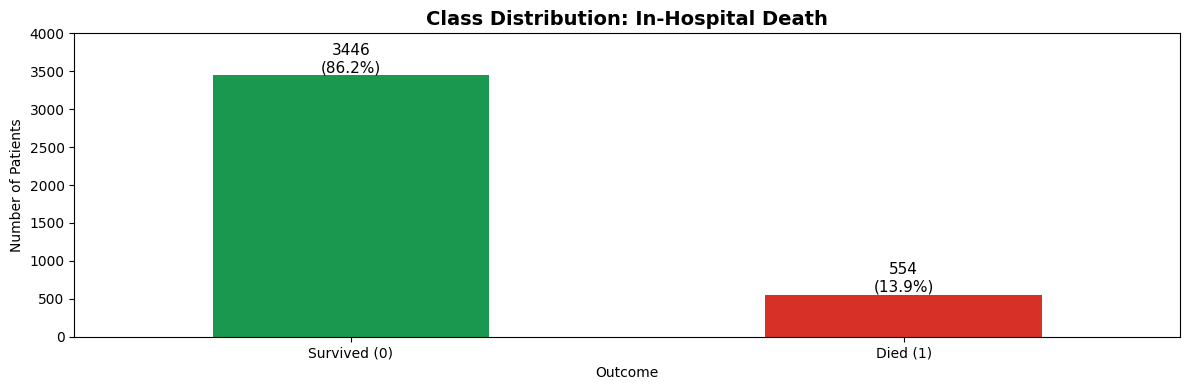

In [45]:
plt.figure(figsize=(12, 4))
ax = merged_cleaned["In-hospital_death"].value_counts().plot(
    kind="bar",
    color=["#1a9850", "#d73027"],
    width=0.5
)

# Add count and percentage labels on each bar
total = len(merged_cleaned)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)

plt.xticks([0, 1], ["Survived (0)", "Died (1)"], rotation=0)
plt.title("Class Distribution: In-Hospital Death", fontsize=14, fontweight="bold")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.ylim(0, 4000)
plt.tight_layout()
plt.show()

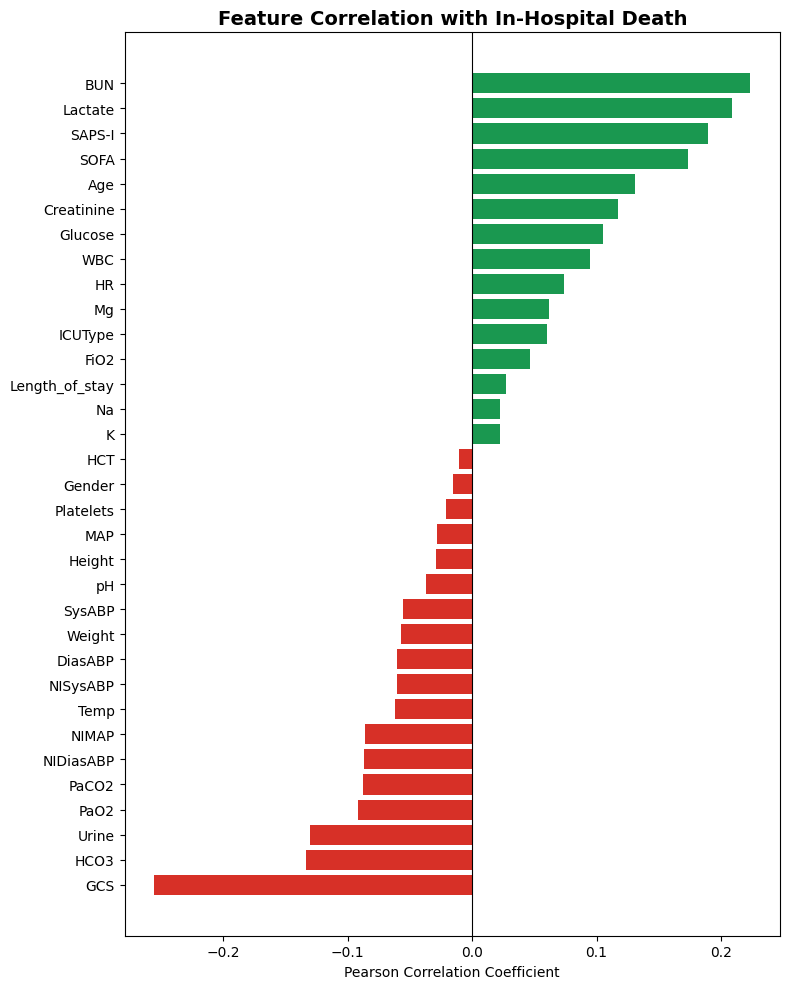

In [46]:
# Compute correlation of all features with the target
target_corr = merged_cleaned.corr()["In-hospital_death"].drop("In-hospital_death")
target_corr = target_corr.sort_values()

plt.figure(figsize=(8, 10))
colors = ["#d73027" if x < 0 else "#1a9850" for x in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with In-Hospital Death", fontsize=14, fontweight="bold")
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

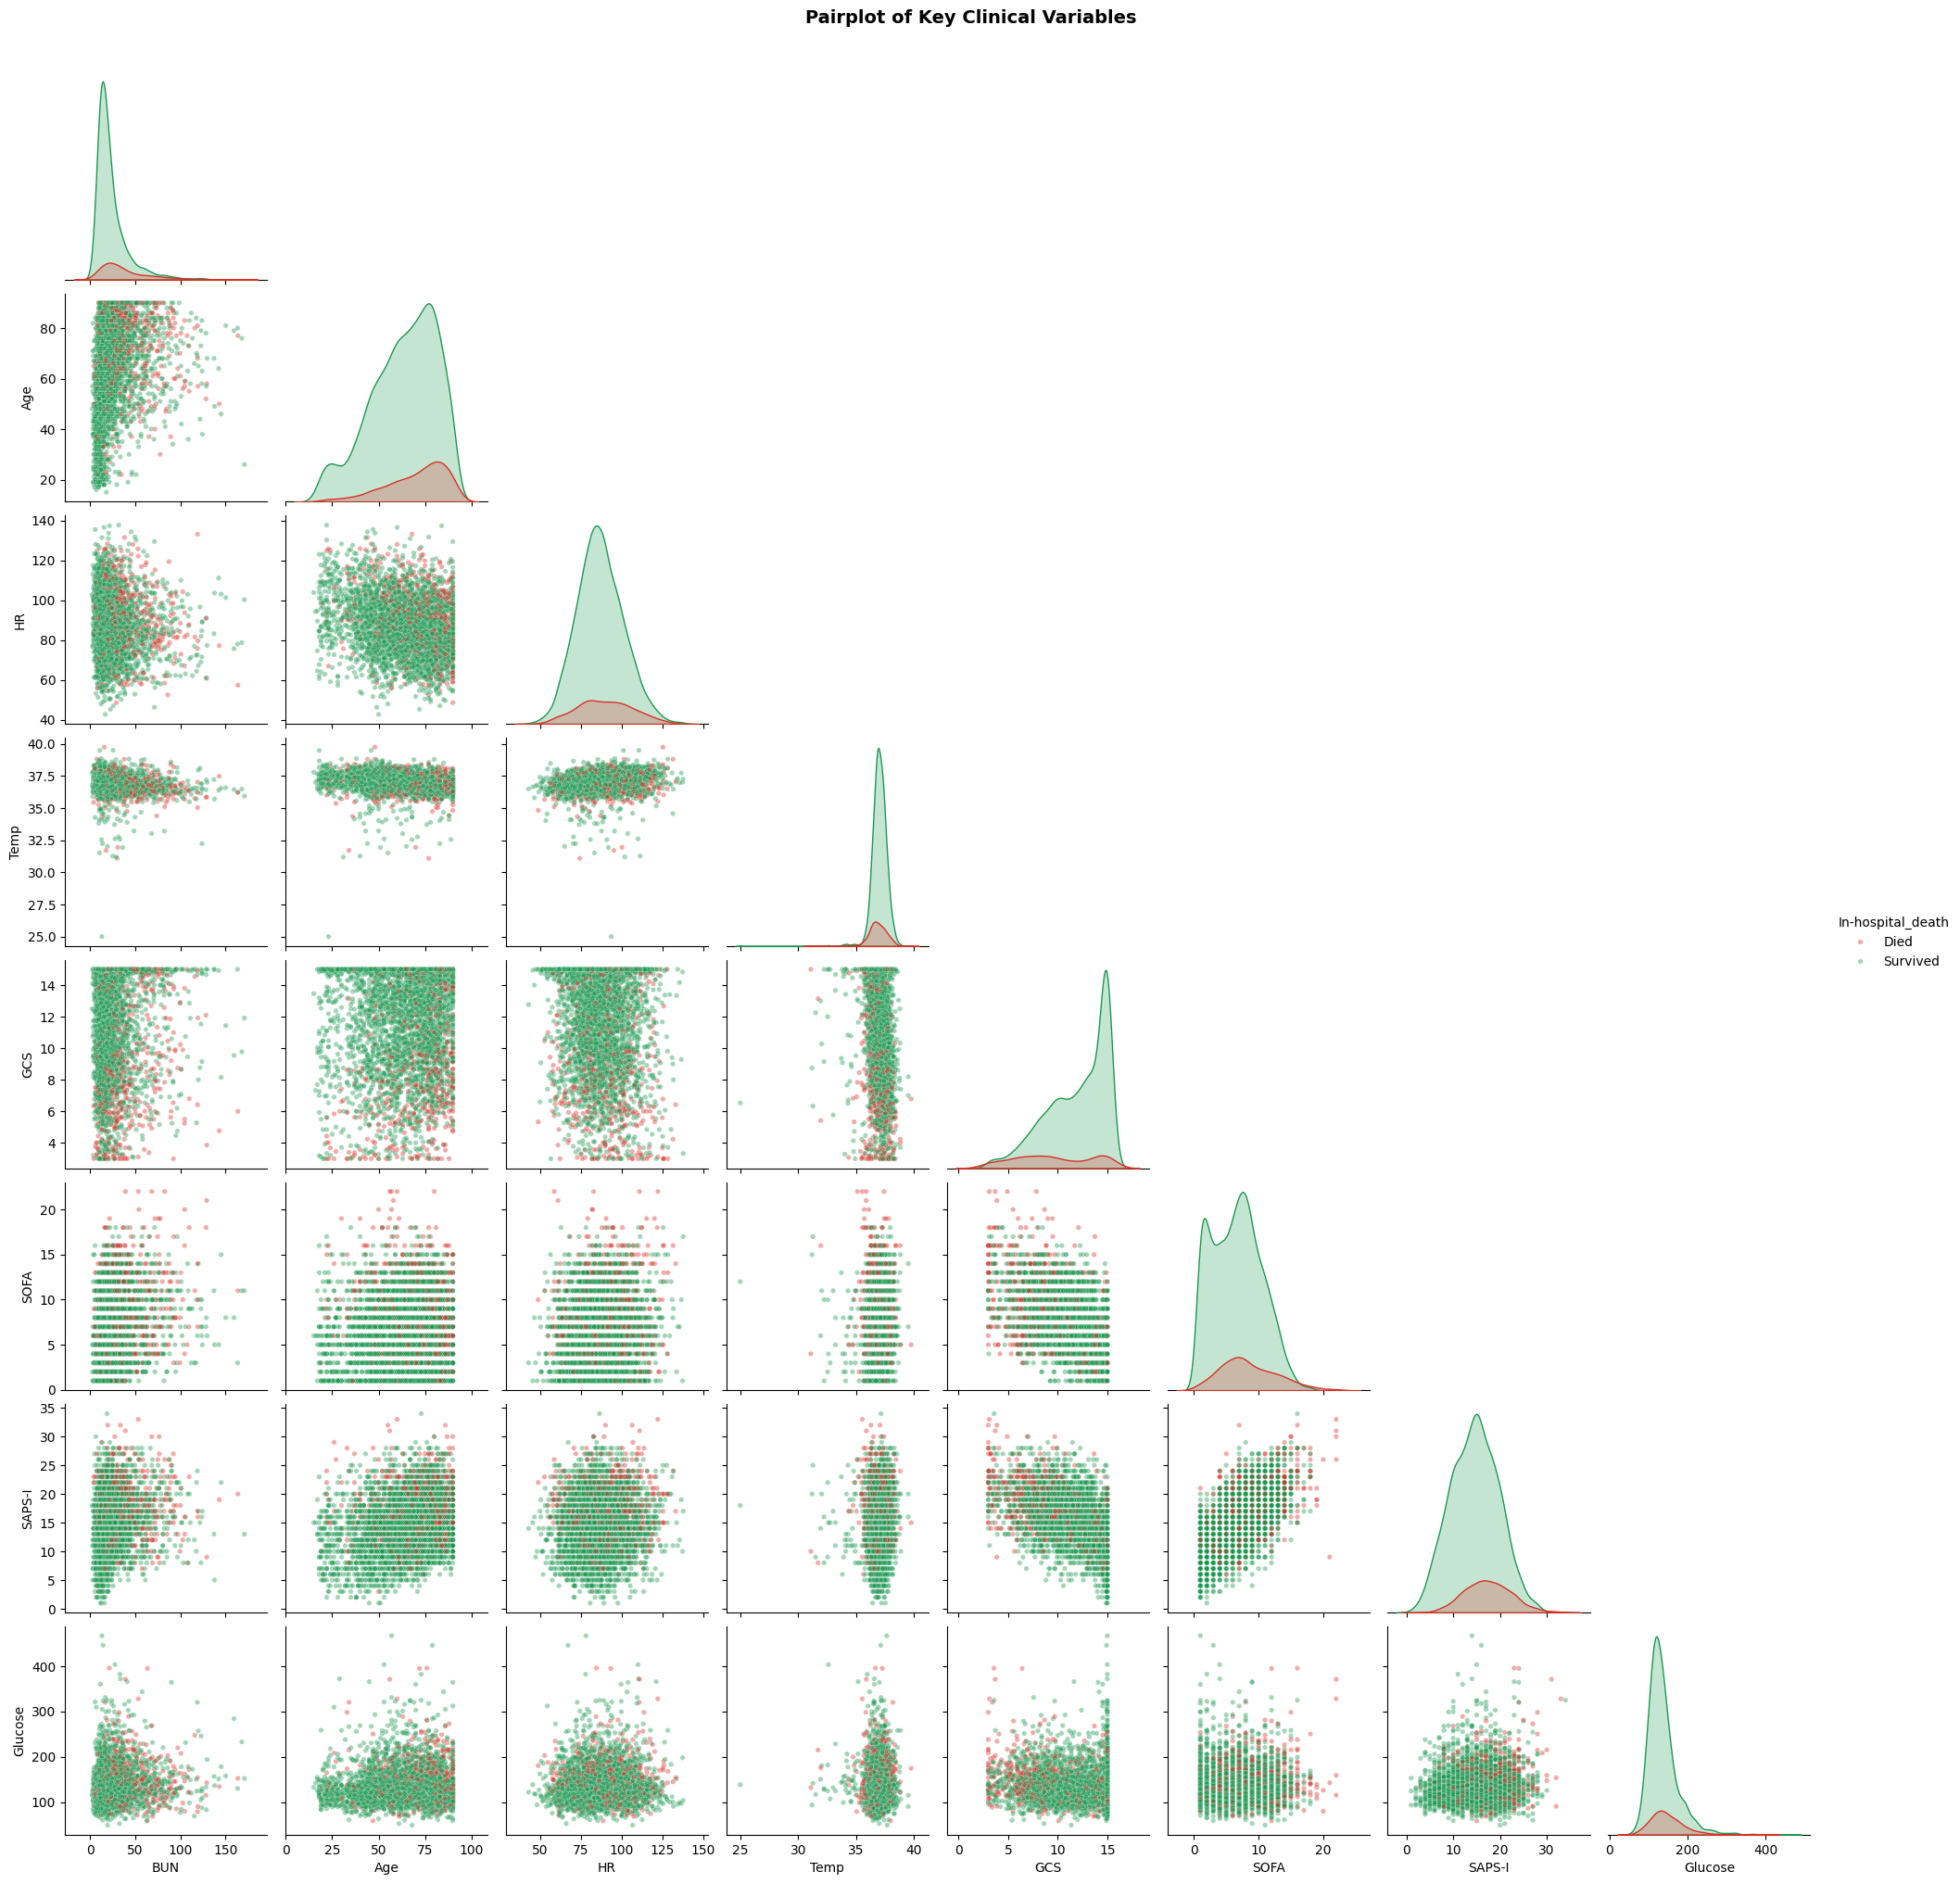

In [52]:
key_vars = ["BUN" , "Age", "HR", "Temp", "GCS", "SOFA", "SAPS-I", "Glucose","In-hospital_death"]

pair_df = merged_cleaned[key_vars].copy()
pair_df["In-hospital_death"] = pair_df["In-hospital_death"].map({0: "Survived", 1: "Died"})

sns.pairplot(
    pair_df,
    hue="In-hospital_death",
    palette={"Survived": "#1a9850", "Died": "#d73027"},
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kind="kde",
    corner=True
)

plt.suptitle("Pairplot of Key Clinical Variables", y=1.02, fontsize=14, fontweight="bold")
plt.show()

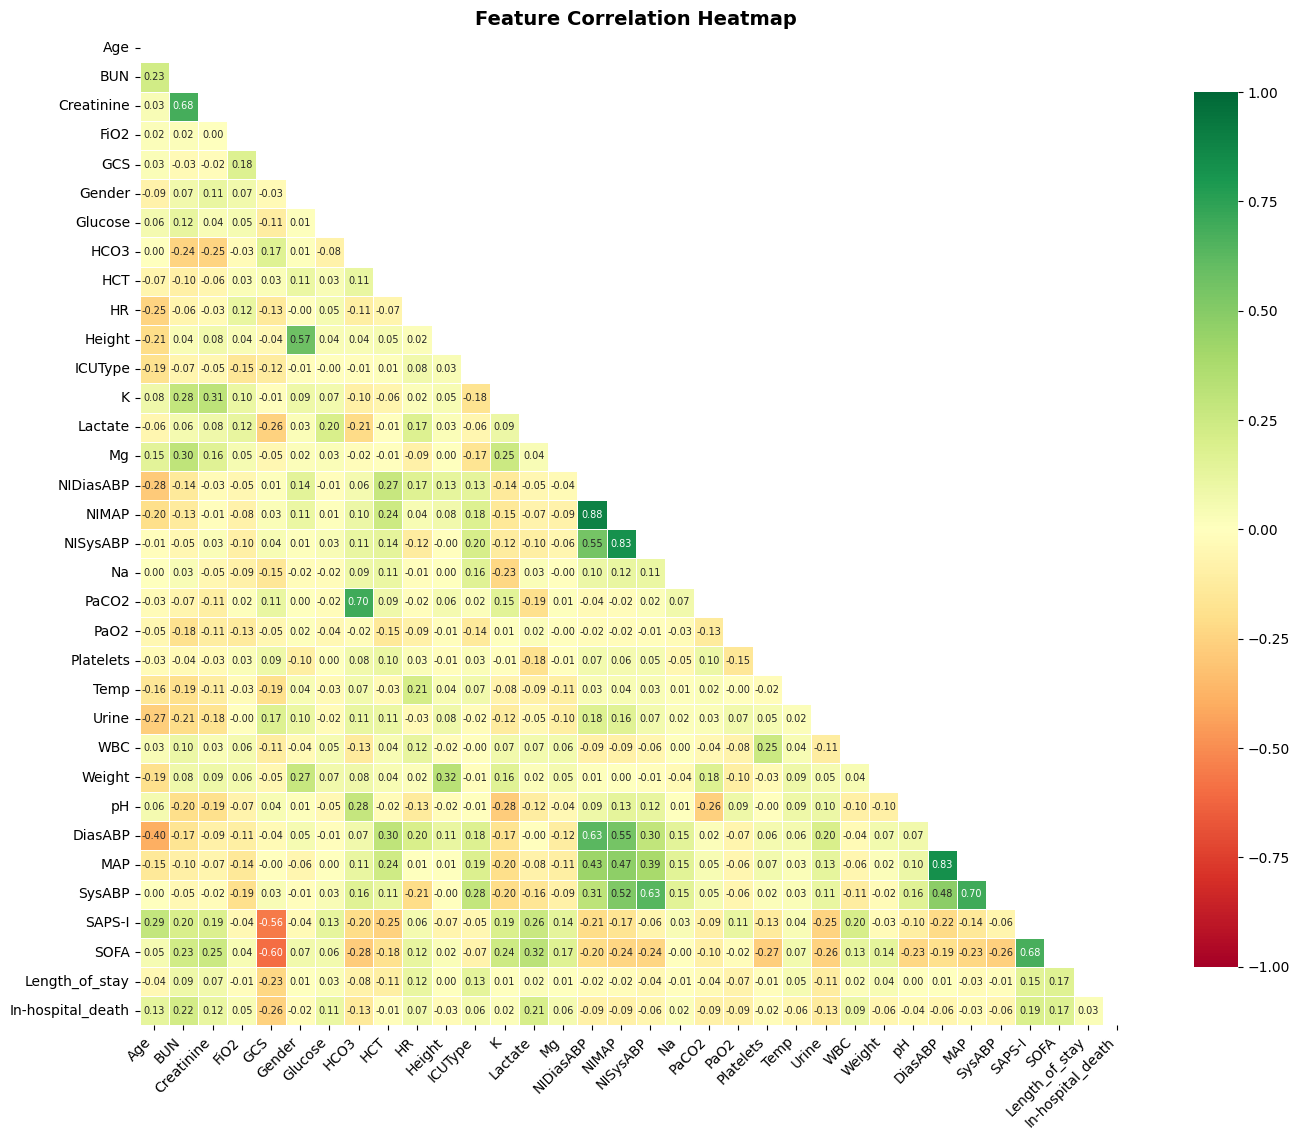

In [55]:
plt.figure(figsize=(14, 12))

corr_matrix = merged_cleaned.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [56]:
X = merged_cleaned.drop(columns=["In-hospital_death"])
y = merged_cleaned['In-hospital_death']

In [57]:
print(X.columns.tolist())

['Age', 'BUN', 'Creatinine', 'FiO2', 'GCS', 'Gender', 'Glucose', 'HCO3', 'HCT', 'HR', 'Height', 'ICUType', 'K', 'Lactate', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'Temp', 'Urine', 'WBC', 'Weight', 'pH', 'DiasABP', 'MAP', 'SysABP', 'SAPS-I', 'SOFA', 'Length_of_stay']


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)
print("Training target shape :", y_train.shape)
print("Testing target shape  :", y_test.shape)

Training feature shape: (2800, 33)
Testing feature shape : (1200, 33)
Training target shape : (2800,)
Testing target shape  : (1200,)


In [65]:
pipeline = Pipeline([
    ("imputer",   SimpleImputer(strategy="median")),
    ("log",       FunctionTransformer(lambda X: np.log1p(np.clip(X, 0, None)), validate=True) ),
    ("scaler",    StandardScaler())
])

X_train = pipeline.fit_transform(X_train)
X_test  = pipeline.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (2800, 33)
X_test shape:  (1200, 33)


In [66]:
print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {pd.Series(y_train).value_counts().to_dict()}")

Before SMOTE: {0: 2412, 1: 388}
After SMOTE:  {0: 2412, 1: 2412}


# Feature selection

In [ ]:
estimator = RandomForestClassifier(n_estimators=100, random_state=42)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring="f1",
    min_features_to_select=5,
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")


In [ ]:
feature_names = X_train.columns  # save before pipeline transforms it
print(f"Selected features: {feature_names[rfecv.support_].tolist()}")

#X_train_selected = rfecv.transform(X_train_resampled)
#X_test_selected  = rfecv.transform(X_test_processed)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"], marker="o", linewidth=1.5)
plt.axvline(rfecv.n_features_, color="red", linestyle="--", label=f"Optimal: {rfecv.n_features_} features")
plt.xlabel("Number of Features")
plt.ylabel("F1 Score (CV)")
plt.title("RFECV - Optimal Feature Selection")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Get feature importances from the RFECV estimator
importances = pd.Series(rfecv.estimator_.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 10))
importances.plot(kind="barh", color="#1a9850")
plt.gca().invert_yaxis()
plt.title("Feature Importances from RFECV Estimator", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Select top N features
top_n = 15
selected_features = importances.head(top_n).index.tolist()
print(f"Top {top_n} features: {selected_features}")

X_train_selected = X_train_resampled[:, [list(feature_names).index(f) for f in selected_features]]
X_test_selected  = X_test_processed[:,  [list(feature_names).index(f) for f in selected_features]]

# Model Training and prediction